In [ ]:
import os
import sys

# 実行環境の確認
if "google.colab" in sys.modules:
    print("✓ Running in Google Colab")
else:
    print("✗ Running locally (not Colab)")

print(f"Python version: {sys.version}")
print(f"Executable: {sys.executable}")
print(f"Working Directory: {os.getcwd()}")

In [11]:
# Colab で実行している場合、リポジトリをクローンする
#!git clone -b master https://github.com/AcademiXBase/deep-learning-from-scratch-2.git
#%cd deep-learning-from-scratch-2

In [12]:
# coding: utf-8
import sys
sys.path.append('..')

import numpy as np

from common.layers import MatMul, SoftmaxWithLoss
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import preprocess, create_contexts_target, convert_one_hot

# word2vecの高速化
第3章では、`SimpleCBOW` と `SimpleSkipGram` を通して word2vec の基本的な仕組みを確認しました。一方で、その実装は小さなコーパスを理解するための最小構成であり、実用的な語彙数になると計算量が大きくなります。

## 高速化が必要になる理由
シンプルな実装では、入力単語を one-hot ベクトルに変換し、`MatMul` レイヤで重み行列と掛け合わせていました。また、出力側では語彙全体に対してスコアを計算し、`SoftmaxWithLoss` で正解単語の確率を求めていました。

語彙数が数万から数百万に増えると、以下の2点が大きなボトルネックになります。

- **入力側の計算**: one-hot ベクトルと巨大な重み行列の積は、実質的には特定の行を取り出しているだけなのに、行列積として扱うと無駄が多い。
- **出力側の計算**: Softmax は語彙全体のスコアを計算するため、1回の学習ごとに全単語を対象にした処理が必要になる。

### 高速化の全体像

```mermaid
flowchart LR
  A[第3章のシンプルな word2vec] --> B[入力側の高速化]
  A --> C[出力側の高速化]
  B --> D[Embedding レイヤ]
  C --> E[Negative Sampling]
  D --> F[高速版 CBOW / Skip-gram]
  E --> F
  F --> G[PTB コーパスで学習]
```

## 本章の目的
本章では、この2つの問題を解決するために、**Embedding レイヤ**と **Negative Sampling（負例サンプリング）** を導入します。

- **Embedding**: one-hot ベクトルとの行列積をやめ、単語 ID を使って重み行列から必要な行だけを直接取り出します。
- **Negative Sampling**: 語彙全体を分類する問題ではなく、「この単語ペアは正しい組み合わせか」を判定する二値分類問題に置き換えます。

これにより、第3章で扱った word2vec の構造を保ったまま、PTB コーパスのような実用に近いデータでも学習できる形へ拡張します。

## Negative Sampling の実装

このコードでは、word2vec の出力側の計算を高速化するために、`EmbeddingDot`、`UnigramSampler`、`NegativeSamplingLoss` の3つのクラスを定義しています。第3章の `SoftmaxWithLoss` は語彙全体を対象にしていましたが、ここでは正例1つと少数の負例だけを使って学習します。

```mermaid
flowchart LR
  T[ターゲット単語] --> P[EmbeddingDot 正例]
  H[中間表現 h] --> P
  H --> N[EmbeddingDot 負例]
  S[UnigramSampler] --> W[負例単語]
  W --> N
  P --> L1[SigmoidWithLoss ラベル1]
  N --> L0[SigmoidWithLoss ラベル0]
  L1 --> Loss[損失を合算]
  L0 --> Loss
```

### 1. `EmbeddingDot`
`EmbeddingDot` は、出力側の重み `W_out` から対象単語のベクトルだけを取り出し、中間表現 `h` との内積を計算するレイヤです。

- **Embedding**: `idx` に対応する単語ベクトル `target_W` を取り出します。
- **内積**: `np.sum(target_W * h, axis=1)` によって、文脈ベクトル `h` と対象単語ベクトルの近さをスコア化します。
- **役割**: 「この文脈に対して、この単語が出現しそうか」を1つのスカラー値として表します。

### 2. `UnigramSampler`
`UnigramSampler` は、負例として使う単語をコーパス中の出現頻度に基づいてサンプリングします。

- **頻度分布の作成**: `collections.Counter` で単語 ID ごとの出現回数を数えます。
- **0.75乗の補正**: `np.power(self.word_p, power)` によって高頻度語の影響を少し弱め、低頻度語も選ばれやすくします。
- **正解単語の除外**: CPU 実行時は、負例にターゲット単語が混ざらないように `p[target_idx] = 0` としています。

### 3. `NegativeSamplingLoss`
`NegativeSamplingLoss` は、正例と負例をまとめて二値分類の損失として計算します。

1. 正例では、実際のターゲット単語に対するスコアを計算し、ラベル `1` として `SigmoidWithLoss` に渡します。
2. 負例では、サンプリングした単語に対するスコアを計算し、ラベル `0` として損失を足し合わせます。
3. 逆伝播では、各 `SigmoidWithLoss` と `EmbeddingDot` から戻る勾配を合算し、前段の中間表現 `h` へ返します。

### 処理の流れ

| 対象 | ラベル | 計算内容 | 意味 |
| :--- | :--- | :--- | :--- |
| 正例の単語 | 1 | `h` と正解単語ベクトルの内積 | 近いほどよい |
| 負例の単語 | 0 | `h` と負例単語ベクトルの内積 | 遠いほどよい |
| 損失 | - | 複数の `SigmoidWithLoss` の合計 | 正例と負例を識別する力を学習 |

> **ポイント**
> Negative Sampling では、全単語に対して Softmax を計算する代わりに、少数のサンプルだけで学習します。これにより、語彙数が大きくなっても1回あたりの計算量を抑えられます。

In [ ]:
# ch04/negative_sampling_layer.py

# coding: utf-8
import sys
sys.path.append('..')
from common.layers import Embedding, SigmoidWithLoss
from common.np import *  # import numpy as np

import collections

class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W * h, axis=1)

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)

        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh


class UnigramSampler:
    def __init__(self, corpus, power, sample_size):
        self.sample_size = sample_size
        self.vocab_size = None
        self.word_p = None

        counts = collections.Counter()
        for word_id in corpus:
            counts[word_id] += 1

        vocab_size = len(counts)
        self.vocab_size = vocab_size

        self.word_p = np.zeros(vocab_size)
        for i in range(vocab_size):
            self.word_p[i] = counts[i]

        self.word_p = np.power(self.word_p, power)
        self.word_p /= np.sum(self.word_p)

    def get_negative_sample(self, target):
        batch_size = target.shape[0]

        if not GPU:
            negative_sample = np.zeros((batch_size, self.sample_size), dtype=np.int32)

            for i in range(batch_size):
                p = self.word_p.copy()
                target_idx = target[i]
                p[target_idx] = 0
                p /= p.sum()
                negative_sample[i, :] = np.random.choice(self.vocab_size, size=self.sample_size, replace=False, p=p)
        else:
            # GPU(cupy）で計算するときは、速度を優先
            # 負例にターゲットが含まれるケースがある
            negative_sample = np.random.choice(self.vocab_size, size=(batch_size, self.sample_size),
                                               replace=True, p=self.word_p)

        return negative_sample


class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        # 正例のフォワード
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        # 負例のフォワード
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout)
            dh += l1.backward(dscore)

        return dh


## `NegativeSamplingLoss` のコードの読み方

直前のコードは、負例サンプリングを1つの損失レイヤとして使えるようにまとめたものです。`CBOW` や `SkipGram` から見ると、`NegativeSamplingLoss` は `h` と正解単語 ID を受け取り、正例と負例を内部で処理して損失を返す部品として振る舞います。

```mermaid
flowchart TD
  C[corpus] --> U[UnigramSampler]
  T[target] --> U
  U --> N[negative_sample]

  %% 中間表現 h からの接続順序を 負例 → 正例 の順に変更して配置を整理します
  H[中間表現 h] --> EN[EmbeddingDot 負例]
  H --> EP[EmbeddingDot 正例]

  N --> EN
  T --> EP

  EN --> LN[SigmoidWithLoss label 0]
  EP --> LP[SigmoidWithLoss label 1]
  LN --> L[loss]
  LP --> L
  L --> B[backward]
  B --> DH[dh を前段へ返す]
```

### 実装上のポイント

- `EmbeddingDot` は、対象単語の出力側ベクトルだけを取り出して `h` との内積を計算します。語彙全体のスコア行列を作らないため、計算量を小さくできます。
- `UnigramSampler` は、コーパス中の単語頻度をもとに負例を選びます。`power=0.75` により、高頻度語に偏りすぎない分布へ調整しています。
- `NegativeSamplingLoss` は、正例用に1個、負例用に `sample_size` 個の `SigmoidWithLoss` と `EmbeddingDot` を持ちます。デフォルトでは正例1個と負例5個を学習対象にします。
- CPU 実行時は負例からターゲット単語を除外します。一方、GPU 実行時は速度を優先して `replace=True` でまとめてサンプリングするため、まれに負例へターゲットが混ざる可能性があります。

このレイヤによって、出力層の学習は「全単語から正解を選ぶ多クラス分類」ではなく、「与えられた単語ペアが正例か負例かを見分ける二値分類」の集合として扱えるようになります。

In [14]:
# ch04/cbow.py

# coding: utf-8
import sys
sys.path.append('..')
from common.np import *  # import numpy as np
from common.layers import Embedding
# from ch04.negative_sampling_layer import NegativeSamplingLoss


class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        # 重みの初期化
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        # レイヤの生成
        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(W_in)  # Embeddingレイヤを使用
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # すべての重みと勾配をリストにまとめる
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        return None


## 高速版 `CBOW` / `SkipGram` の実装

ここでは、第3章の `SimpleCBOW` と `SimpleSkipGram` を、Embedding レイヤと Negative Sampling を使う形に置き換えています。モデルの予測方向は同じですが、入力側と出力側の計算方法が高速化されています。

### CBOW と Skip-gram の予測方向

```mermaid
flowchart LR
  subgraph CBOW[CBOW]
    C1[周辺語1] --> CE1[Embedding]
    C2[周辺語2] --> CE2[Embedding]
    CE1 --> H1[平均ベクトル h]
    CE2 --> H1
    H1 --> NS1[NegativeSamplingLoss]
    T1[中央のターゲット語] --> NS1
  end

  subgraph SG[Skip-gram]
    T2[中央のターゲット語] --> SE[Embedding]
    SE --> H2[中間表現 h]
    H2 --> NS2[NegativeSamplingLoss]
    H2 --> NS3[NegativeSamplingLoss]
    C3[左の周辺語] --> NS2
    C4[右の周辺語] --> NS3
  end
```

## `CBOW` クラス
`CBOW` は、周囲の単語（コンテキスト）から中央の単語（ターゲット）を予測するモデルです。

### 1. 初期化 (`__init__`)

- **`W_in`**: 入力側の重みです。各単語 ID に対応する埋め込みベクトルを保持し、学習後は `word_vecs` として利用されます。
- **`W_out`**: 出力側の重みです。Negative Sampling の正例・負例判定で使われます。
- **`Embedding` レイヤ**: コンテキストの数だけ作成されます。`window_size = 5` なら、左右5語ずつ、合計10個の入力レイヤになります。
- **`NegativeSamplingLoss`**: 語彙全体への Softmax の代わりに、ターゲット単語と負例単語だけを使って損失を計算します。

### 2. 順伝播 (`forward`)
各コンテキスト単語の埋め込みを取り出し、それらを足し合わせて平均したものを中間表現 `h` とします。その後、`NegativeSamplingLoss` に `h` と `target` を渡して損失を求めます。

### 3. 逆伝播 (`backward`)
`NegativeSamplingLoss` から戻ってきた勾配を、平均化の処理に合わせてコンテキスト数で割り、すべての `Embedding` レイヤへ同じ勾配を流します。

## `SkipGram` クラス
`SkipGram` は、中央の単語（ターゲット）から周囲の単語（コンテキスト）を予測するモデルです。

- **入力側**: ターゲット単語を1つの `Embedding` レイヤに通し、中間表現 `h` を得ます。
- **出力側**: コンテキストの数だけ `NegativeSamplingLoss` を用意し、それぞれの周辺語を正例として学習します。
- **損失**: 各コンテキスト語に対する損失を足し合わせます。
- **勾配**: 複数の `NegativeSamplingLoss` から戻る勾配を合算し、入力側の `Embedding` レイヤへ戻します。

### 第3章の実装との比較

| 項目 | 第3章のシンプル実装 | 第4章の高速版 |
| :--- | :--- | :--- |
| 入力表現 | one-hot ベクトル | 単語 ID |
| 入力側の計算 | `MatMul` | `Embedding` による行抽出 |
| 出力側の損失 | `SoftmaxWithLoss` | `NegativeSamplingLoss` |
| 出力の対象 | 語彙全体 | 正例1語 + 負例数語 |
| 主な利点 | 構造が理解しやすい | 大規模コーパスで学習しやすい |

> **ポイント**
> モデルの本質は第3章と同じです。CBOW は「文脈からターゲット」、Skip-gram は「ターゲットから文脈」を予測します。ただし、計算対象を必要な単語に絞ることで、実用規模の語彙にも対応できるようになります。

In [ ]:
# ch04/skip_gram.py

# coding: utf-8
import sys
sys.path.append('..')  # 親ディレクトリのファイルをインポートするための設定
from common.layers import *
# from ch04.negative_sampling_layer import NegativeSamplingLoss


class SkipGram:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size
        rn = np.random.randn

        # 重みの初期化
        W_in = 0.01 * rn(V, H).astype('f')
        W_out = 0.01 * rn(V, H).astype('f')

        # レイヤの生成
        self.in_layer = Embedding(W_in)
        self.loss_layers = []
        for i in range(2 * window_size):
            layer = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)
            self.loss_layers.append(layer)

        # すべての重みと勾配をリストにまとめる
        layers = [self.in_layer] + self.loss_layers
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = self.in_layer.forward(target)

        loss = 0
        for i, layer in enumerate(self.loss_layers):
            loss += layer.forward(h, contexts[:, i])
        return loss

    def backward(self, dout=1):
        dh = 0
        for i, layer in enumerate(self.loss_layers):
            dh += layer.backward(dout)
        self.in_layer.backward(dh)
        return None


## PTB コーパスでの学習（CPU）

このセクションでは、Penn Treebank（PTB）コーパスを使って高速版 word2vec を学習します。第3章では短い例文を使いましたが、ここではより大きなコーパスを扱うため、Embedding と Negative Sampling の効果が重要になります。

```mermaid
flowchart LR
  A[PTB train] --> B[create_contexts_target]
  B --> C[contexts と target]
  C --> D[CBOW または Skip-gram]
  D --> E[Trainer.fit]
  E --> F[損失をプロット]
  D --> G[word_vecs]
  G --> H[cbow_params.pkl]
```

### 1. 学習設定

- **`window_size = 5`**: ターゲットの左右5語、合計10語をコンテキストとして扱います。
- **`hidden_size = 100`**: 単語ベクトルの次元数を100に設定します。
- **`batch_size = 4096`**: 1回の更新でまとめて処理するデータ数です。
- **`max_epoch = 10`**: コーパス全体を10回繰り返して学習します。

### 2. データの準備
`ptb.load_data('train')` で学習用コーパスを読み込み、`create_contexts_target` でコンテキストとターゲットのペアを作成します。第3章と異なり、ここでは one-hot 化を行いません。`Embedding` レイヤが単語 ID をそのまま受け取れるためです。

### 3. 学習の実行
モデルには `CBOW` を使っています。`SkipGram` を試したい場合は、モデル生成部分のコメントを切り替えることで同じ学習ループを利用できます。

学習は `Trainer.fit()` によって進み、`trainer.plot()` で損失の推移を確認します。損失が徐々に下がっていれば、文脈と単語の関係をモデルが学習できていると考えられます。

### 4. 学習済みパラメータの保存
最後に、入力側の重み `model.word_vecs` を `cbow_params.pkl` に保存します。この重みが学習済みの単語分散表現です。評価用コードでは、このファイルを読み込んで類似単語検索やアナロジー問題に利用します。

| epoch 1 |  iter 1 / 226 | time 0[s] | loss 4.16
| epoch 1 |  iter 21 / 226 | time 0[s] | loss 4.15
| epoch 1 |  iter 41 / 226 | time 0[s] | loss 4.08
| epoch 1 |  iter 61 / 226 | time 0[s] | loss 3.84
| epoch 1 |  iter 81 / 226 | time 0[s] | loss 3.46
| epoch 1 |  iter 101 / 226 | time 0[s] | loss 3.10
| epoch 1 |  iter 121 / 226 | time 0[s] | loss 2.85
| epoch 1 |  iter 141 / 226 | time 1[s] | loss 2.72
| epoch 1 |  iter 161 / 226 | time 1[s] | loss 2.64
| epoch 1 |  iter 181 / 226 | time 1[s] | loss 2.60
| epoch 1 |  iter 201 / 226 | time 1[s] | loss 2.58
| epoch 1 |  iter 221 / 226 | time 1[s] | loss 2.57
| epoch 2 |  iter 1 / 226 | time 1[s] | loss 2.56
| epoch 2 |  iter 21 / 226 | time 1[s] | loss 2.55
| epoch 2 |  iter 41 / 226 | time 1[s] | loss 2.55
| epoch 2 |  iter 61 / 226 | time 2[s] | loss 2.54
| epoch 2 |  iter 81 / 226 | time 2[s] | loss 2.54
| epoch 2 |  iter 101 / 226 | time 2[s] | loss 2.53
| epoch 2 |  iter 121 / 226 | time 2[s] | loss 2.53
| epoch 2 |  iter 141 / 

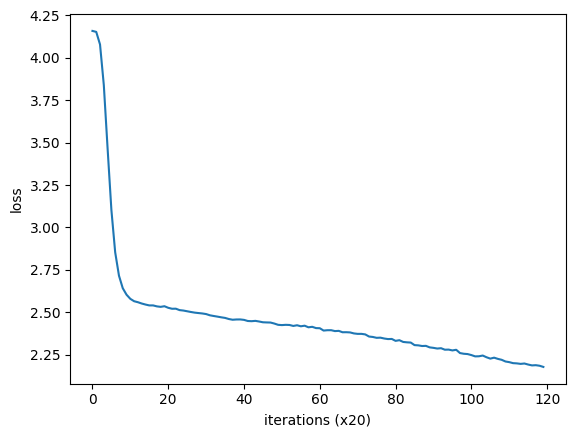

In [ ]:
"""
CPUで学習
"""

# ch04/train.py

# coding: utf-8
import sys
sys.path.append('..')
from common import config
# GPUで実行する場合は、下記のコメントアウトを消去（要cupy）
# ===============================================
# config.GPU = True
# ===============================================
from common.np import *
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
# from cbow import CBOW
# from skip_gram import SkipGram
from common.util import create_contexts_target, to_cpu, to_gpu
from dataset import ptb


# ハイパーパラメータの設定
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 10

# データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)

# モデルなどの生成
model = CBOW(vocab_size, hidden_size, window_size, corpus)
# model = SkipGram(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 学習開始
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 後ほど利用できるように、必要なデータを保存
word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)
params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = '../ch04/cbow_params.pkl'  # or 'skipgram_params.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)

## CPU 学習コードの読み方と GPU 版へのつながり

直前のコードは、PTB コーパスを読み込み、`CBOW` モデルを CPU 環境で学習して、学習済み単語ベクトルを `cbow_params.pkl` に保存する一連の流れです。保存されたパラメータは、後続の評価コードでそのまま利用します。

```mermaid
flowchart LR
  A[ptb.load_data train] --> B[corpus word_to_id id_to_word]
  B --> C[create_contexts_target]
  C --> D[contexts target]
  D --> E[CBOW]
  E --> F[Trainer.fit]
  F --> G[trainer.plot]
  E --> H[word_vecs]
  H --> I[float16 に変換]
  I --> J[cbow_params.pkl]
```

### 学習コードの流れ

1. `ptb.load_data('train')` で、単語 ID 列として表現されたコーパスと辞書を読み込みます。
2. `create_contexts_target(corpus, window_size)` で、周辺語 `contexts` と中央語 `target` の教師データを作ります。
3. `CBOW(vocab_size, hidden_size, window_size, corpus)` でモデルを初期化します。`corpus` は負例サンプリングの確率分布を作るためにも使われます。
4. `Trainer.fit()` でミニバッチ学習を行い、`trainer.plot()` で損失の推移を確認します。
5. 学習後の `model.word_vecs` を保存します。これは入力側の重み `W_in` であり、単語の分散表現として使います。

### CPU 版と GPU 版の違い

次のコードセルでは `config.GPU = True` に切り替え、`common.np` や `common.layers` を再読み込みします。このリポジトリでは `common.np` が `config.GPU` の値を見て NumPy / CuPy を切り替える構造になっているためです。

| 項目 | CPU 版 | GPU 版 |
| :--- | :--- | :--- |
| 配列ライブラリ | NumPy | CuPy |
| `config.GPU` | `False` のまま | `True` に設定 |
| データ転送 | 不要 | `to_gpu` / `to_cpu` を使用 |
| 負例サンプリング | ターゲットを除外 | 速度優先で一括サンプリング |
| 保存前処理 | 必要なら `to_cpu` | 必ず `to_cpu` で NumPy 配列へ戻す |

> **ポイント**
> GPU で学習した配列は CuPy 配列になるため、そのまま `pickle` に保存すると後で CPU 環境で扱いにくくなります。そのため、保存前に `to_cpu(word_vecs)` で NumPy 配列へ戻しています。

------------------------------------------------------------
                       GPU Mode (cupy)
------------------------------------------------------------

| epoch 1 |  iter 1 / 226 | time 0[s] | loss 4.16
| epoch 1 |  iter 21 / 226 | time 0[s] | loss 4.15
| epoch 1 |  iter 41 / 226 | time 0[s] | loss 4.08
| epoch 1 |  iter 61 / 226 | time 0[s] | loss 3.84
| epoch 1 |  iter 81 / 226 | time 0[s] | loss 3.47
| epoch 1 |  iter 101 / 226 | time 0[s] | loss 3.10
| epoch 1 |  iter 121 / 226 | time 0[s] | loss 2.85
| epoch 1 |  iter 141 / 226 | time 1[s] | loss 2.72
| epoch 1 |  iter 161 / 226 | time 1[s] | loss 2.64
| epoch 1 |  iter 181 / 226 | time 1[s] | loss 2.60
| epoch 1 |  iter 201 / 226 | time 1[s] | loss 2.58
| epoch 1 |  iter 221 / 226 | time 1[s] | loss 2.56
| epoch 2 |  iter 1 / 226 | time 1[s] | loss 2.56
| epoch 2 |  iter 21 / 226 | time 1[s] | loss 2.55
| epoch 2 |  iter 41 / 226 | time 1[s] | loss 2.54
| epoch 2 |  iter 61 / 226 | time 2[s] | loss 2.54
| epoch 2 |  iter

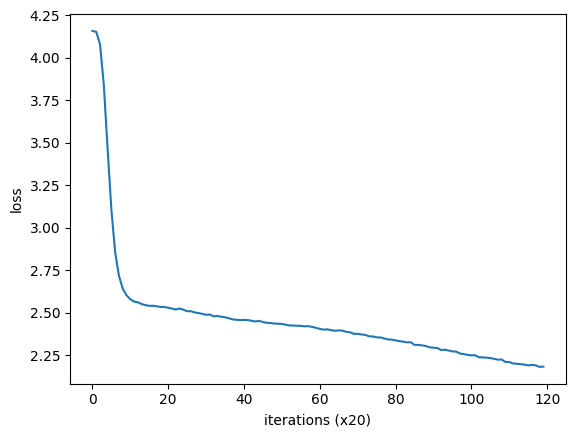

In [17]:
"""
GPUで学習
"""

# coding: utf-8
import sys
sys.path.append('..')

from common import config
import importlib

# GPUで実行
config.GPU = True

import common.np
import common.layers
# import ch04.negative_sampling_layer
# import ch04.cbow
importlib.reload(common.np)
importlib.reload(common.layers)
# importlib.reload(ch04.negative_sampling_layer)
# importlib.reload(ch04.cbow)

from common.np import *
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import create_contexts_target, to_cpu, to_gpu
from dataset import ptb
# from ch04.cbow import CBOW

# from skip_gram import SkipGram


# ハイパーパラメータの設定
window_size = 5
hidden_size = 100
batch_size = 4096
max_epoch = 10

# データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)

if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)

# モデルなどの生成
model = CBOW(vocab_size, hidden_size, window_size, corpus)
# model = SkipGram(vocab_size, hidden_size, window_size, corpus)

optimizer = Adam()
trainer = Trainer(model, optimizer)

# 学習開始
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 後ほど利用できるように、必要なデータを保存
word_vecs = model.word_vecs

# 保存時はNumPy配列に戻す
word_vecs = to_cpu(word_vecs)

params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word

pkl_file = '../ch04/cbow_params.pkl'  # or 'skipgram_params.pkl'

with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)

## 学習済みベクトルの評価

この最後のコードでは、保存した `cbow_params.pkl` を読み込み、学習済み単語ベクトルの性質を確認します。評価には、`common.util` に用意されている `most_similar` と `analogy` を使います。

```mermaid
flowchart LR
  A[cbow_params.pkl] --> B[word_vecs]
  A --> C[word_to_id と id_to_word]
  B --> D[most_similar]
  C --> D
  B --> E[analogy]
  C --> E
  D --> F[類似単語の確認]
  E --> G[単語関係の確認]
```

### 1. 類似単語の確認 (`most_similar`)
`most_similar` は、指定した単語ベクトルとコサイン類似度が高い単語を表示します。

- `you` の近くに代名詞や会話で使われやすい単語が現れるか
- `year` の近くに `month` や `week` など時間に関係する単語が現れるか
- `car` や `toyota` の近くに意味的に関連する単語が現れるか

この結果を見ることで、似た文脈で使われる単語がベクトル空間上でも近い位置に配置されているかを確認できます。

### 2. アナロジー問題 (`analogy`)
`analogy` は、単語ベクトルの差分を使って「A と B の関係は、C と何の関係に近いか」を調べます。

例として、`king:man = queen:?` では、ベクトル演算としておおよそ次の形を考えます。

$$
\mathrm{vec}(man) - \mathrm{vec}(king) + \mathrm{vec}(queen)
$$

この結果に近い単語を探すことで、単語ベクトルが意味的・文法的な関係をどの程度捉えているかを確認します。

### 評価時の注意
出力結果は、学習回数、ランダム初期値、モデルの種類、コーパスサイズによって変わります。特に小さめの学習設定では、すべてのクエリで直感的に正しい単語が出るとは限りません。重要なのは、損失の低下と、類似語・アナロジーの結果に意味的な傾向が現れているかを観察することです。

In [18]:
# ch04/eval.py

# coding: utf-8
import sys
sys.path.append('..')
from common.util import most_similar, analogy
import pickle


pkl_file = '../ch04/cbow_params.pkl'
# pkl_file = 'skipgram_params.pkl'

with open(pkl_file, 'rb') as f:
    params = pickle.load(f)
    word_vecs = params['word_vecs']
    word_to_id = params['word_to_id']
    id_to_word = params['id_to_word']

# most similar task
querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)

# analogy task
print('-'*50)
analogy('king', 'man', 'queen',  word_to_id, id_to_word, word_vecs)
analogy('take', 'took', 'go',  word_to_id, id_to_word, word_vecs)
analogy('car', 'cars', 'child',  word_to_id, id_to_word, word_vecs)
analogy('good', 'better', 'bad',  word_to_id, id_to_word, word_vecs)



[query] you
 we: 0.97900390625
 something: 0.96826171875
 feel: 0.96728515625
 why: 0.966796875
 i: 0.966796875

[query] year
 month: 0.94970703125
 week: 0.8818359375
 earlier: 0.875
 forecast: 0.85498046875
 summer: 0.84814453125

[query] car
 contest: 0.93798828125
 strike: 0.93505859375
 engine: 0.93505859375
 tree: 0.9306640625
 exemption: 0.92822265625

[query] toyota
 reebok: 0.92626953125
 kobe: 0.9248046875
 tennessee: 0.9189453125
 mci: 0.9189453125
 cleveland: 0.9189453125
--------------------------------------------------

[analogy] king:man = queen:?
 know: 5.2578125
 lot: 4.47265625
 thing: 4.33203125
 think: 4.3125
 problem: 4.3125

[analogy] take:took = go:?
 yield: 3.8671875
 composite: 3.83203125
 cents: 3.826171875
 know: 3.751953125
 daffynition: 3.6875

[analogy] car:cars = child:?
 yield: 4.16796875
 daffynition: 4.0
 a.m: 3.9765625
 cents: 3.826171875
 revenue: 3.57421875

[analogy] good:better = bad:?
 know: 4.04296875
 want: 4.02734375
 able: 3.974609375
 do: 

## 本章のまとめ

- **Embedding レイヤ**により、one-hot ベクトルとの行列積を、単語 ID による重み行の抽出へ置き換えました。
- **Negative Sampling**により、語彙全体の Softmax ではなく、正例と少数の負例を使う二値分類問題として学習しました。
- **高速版 CBOW / Skip-gram**により、word2vec の基本構造を保ちながら、より大きなコーパスで学習できる形に拡張しました。
- **評価コード**では、類似単語検索とアナロジー問題を通して、学習済み単語ベクトルが意味的な関係を捉えているかを確認しました。